In [2]:
!pip install pandas seaborn numpy pandas matplotlib 
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_csv('hypertension_dataset.csv')


In [6]:
df.shape

(174982, 23)

In [7]:
df.dtypes

Country                     object
Age                          int64
BMI                        float64
Cholesterol                  int64
Systolic_BP                  int64
Diastolic_BP                 int64
Smoking_Status              object
Alcohol_Intake             float64
Physical_Activity_Level     object
Family_History              object
Diabetes                    object
Stress_Level                 int64
Salt_Intake                float64
Sleep_Duration             float64
Heart_Rate                   int64
LDL                          int64
HDL                          int64
Triglycerides                int64
Glucose                      int64
Gender                      object
Education_Level             object
Employment_Status           object
Hypertension                object
dtype: object

In [8]:
df.head(10)

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,...,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,Yes,...,6.1,80,100,75,72,179,Female,Primary,Unemployed,High
1,Spain,34,36.2,201,120,84,Never,27.5,High,Yes,...,9.8,56,77,47,90,113,Male,Secondary,Unemployed,High
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,Yes,...,5.2,75,162,56,81,101,Male,Primary,Employed,Low
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,Yes,...,7.5,71,164,93,94,199,Female,Secondary,Retired,High
4,France,73,21.8,296,91,97,Never,29.1,Moderate,Yes,...,5.0,52,108,74,226,157,Female,Primary,Employed,High
5,UK,44,31.5,293,158,118,Former,20.3,Moderate,No,...,8.1,98,81,69,181,85,Male,Tertiary,Employed,High
6,South Korea,88,30.9,263,118,62,Current,8.6,Low,Yes,...,4.0,88,114,52,139,194,Male,Secondary,Employed,Low
7,Canada,25,18.1,151,175,101,Never,16.6,Low,Yes,...,5.8,99,154,34,132,193,Female,Secondary,Employed,High
8,Canada,89,19.0,198,102,104,Former,10.5,Low,Yes,...,6.6,56,157,81,145,161,Female,Primary,Retired,Low
9,Brazil,33,39.1,268,168,98,Current,20.7,Moderate,No,...,8.0,76,89,37,223,164,Male,Primary,Retired,High


In [9]:

#missing values
missing_values = df.isnull().sum()

missing_values


Country                    0
Age                        0
BMI                        0
Cholesterol                0
Systolic_BP                0
Diastolic_BP               0
Smoking_Status             0
Alcohol_Intake             0
Physical_Activity_Level    0
Family_History             0
Diabetes                   0
Stress_Level               0
Salt_Intake                0
Sleep_Duration             0
Heart_Rate                 0
LDL                        0
HDL                        0
Triglycerides              0
Glucose                    0
Gender                     0
Education_Level            0
Employment_Status          0
Hypertension               0
dtype: int64

In [5]:

# Sperate the
X = df.drop(columns=["Hypertension"])
y = df["Hypertension"]



In [6]:
# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


categorical_cols


/tmp/ipykernel_51998/2505293736.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


['Country',
 'Smoking_Status',
 'Physical_Activity_Level',
 'Family_History',
 'Diabetes',
 'Gender',
 'Education_Level',
 'Employment_Status']

In [7]:
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
numeric_cols

['Age',
 'BMI',
 'Cholesterol',
 'Systolic_BP',
 'Diastolic_BP',
 'Alcohol_Intake',
 'Stress_Level',
 'Salt_Intake',
 'Sleep_Duration',
 'Heart_Rate',
 'LDL',
 'HDL',
 'Triglycerides',
 'Glucose']

AttributeError: module 'matplotlib' has no attribute 'show'

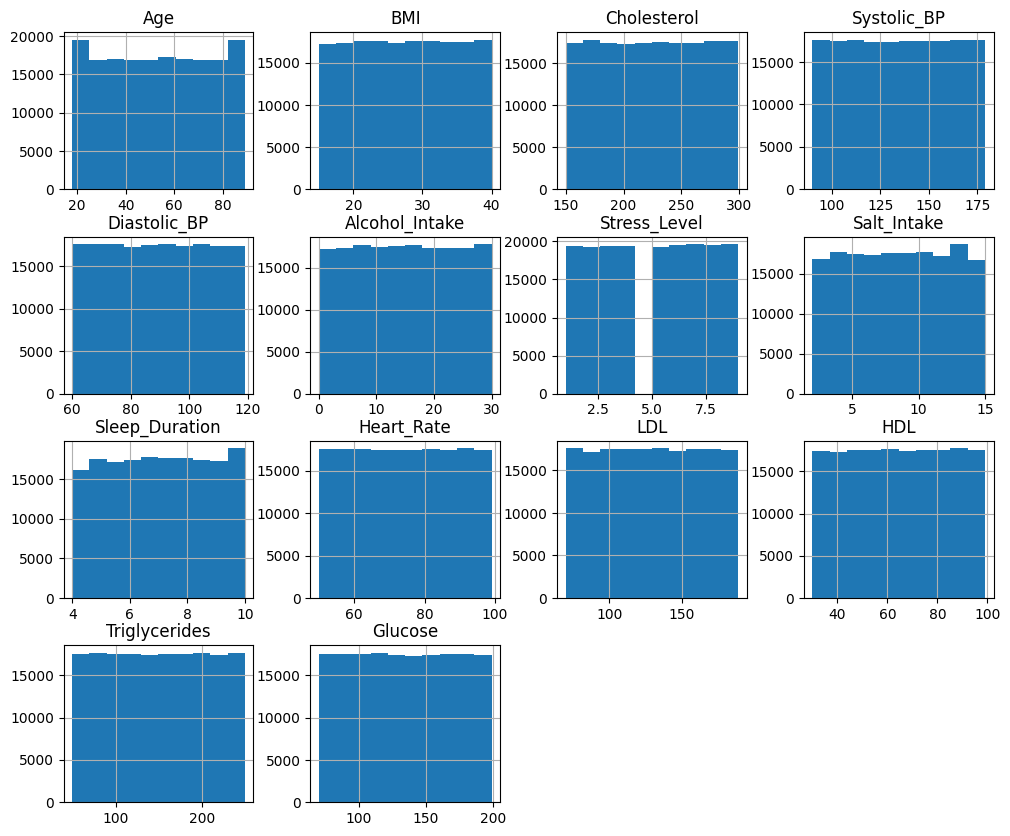

In [11]:
df.hist(figsize=(12,10))
plt.show()

# Univariate Analysis 

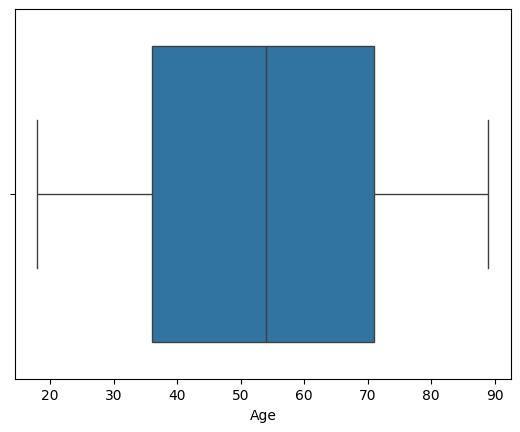

In [14]:
# Box plot of the Age 
sns.boxplot(x=df['Age'])
plt.show()

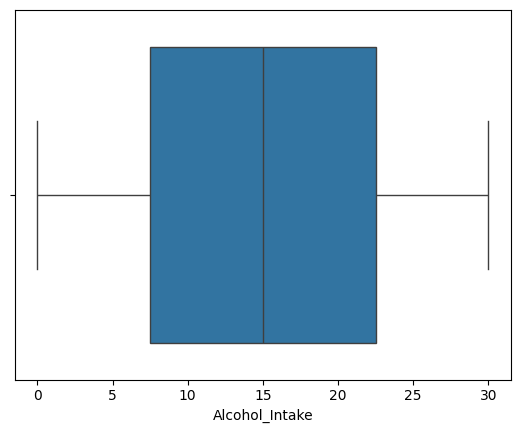

In [15]:
sns.boxplot(x=df['Alcohol_Intake'])
plt.show()

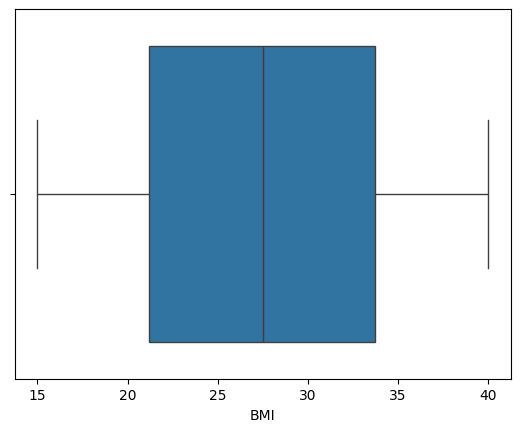

In [16]:
sns.boxplot(x=df['BMI'])
plt.show()

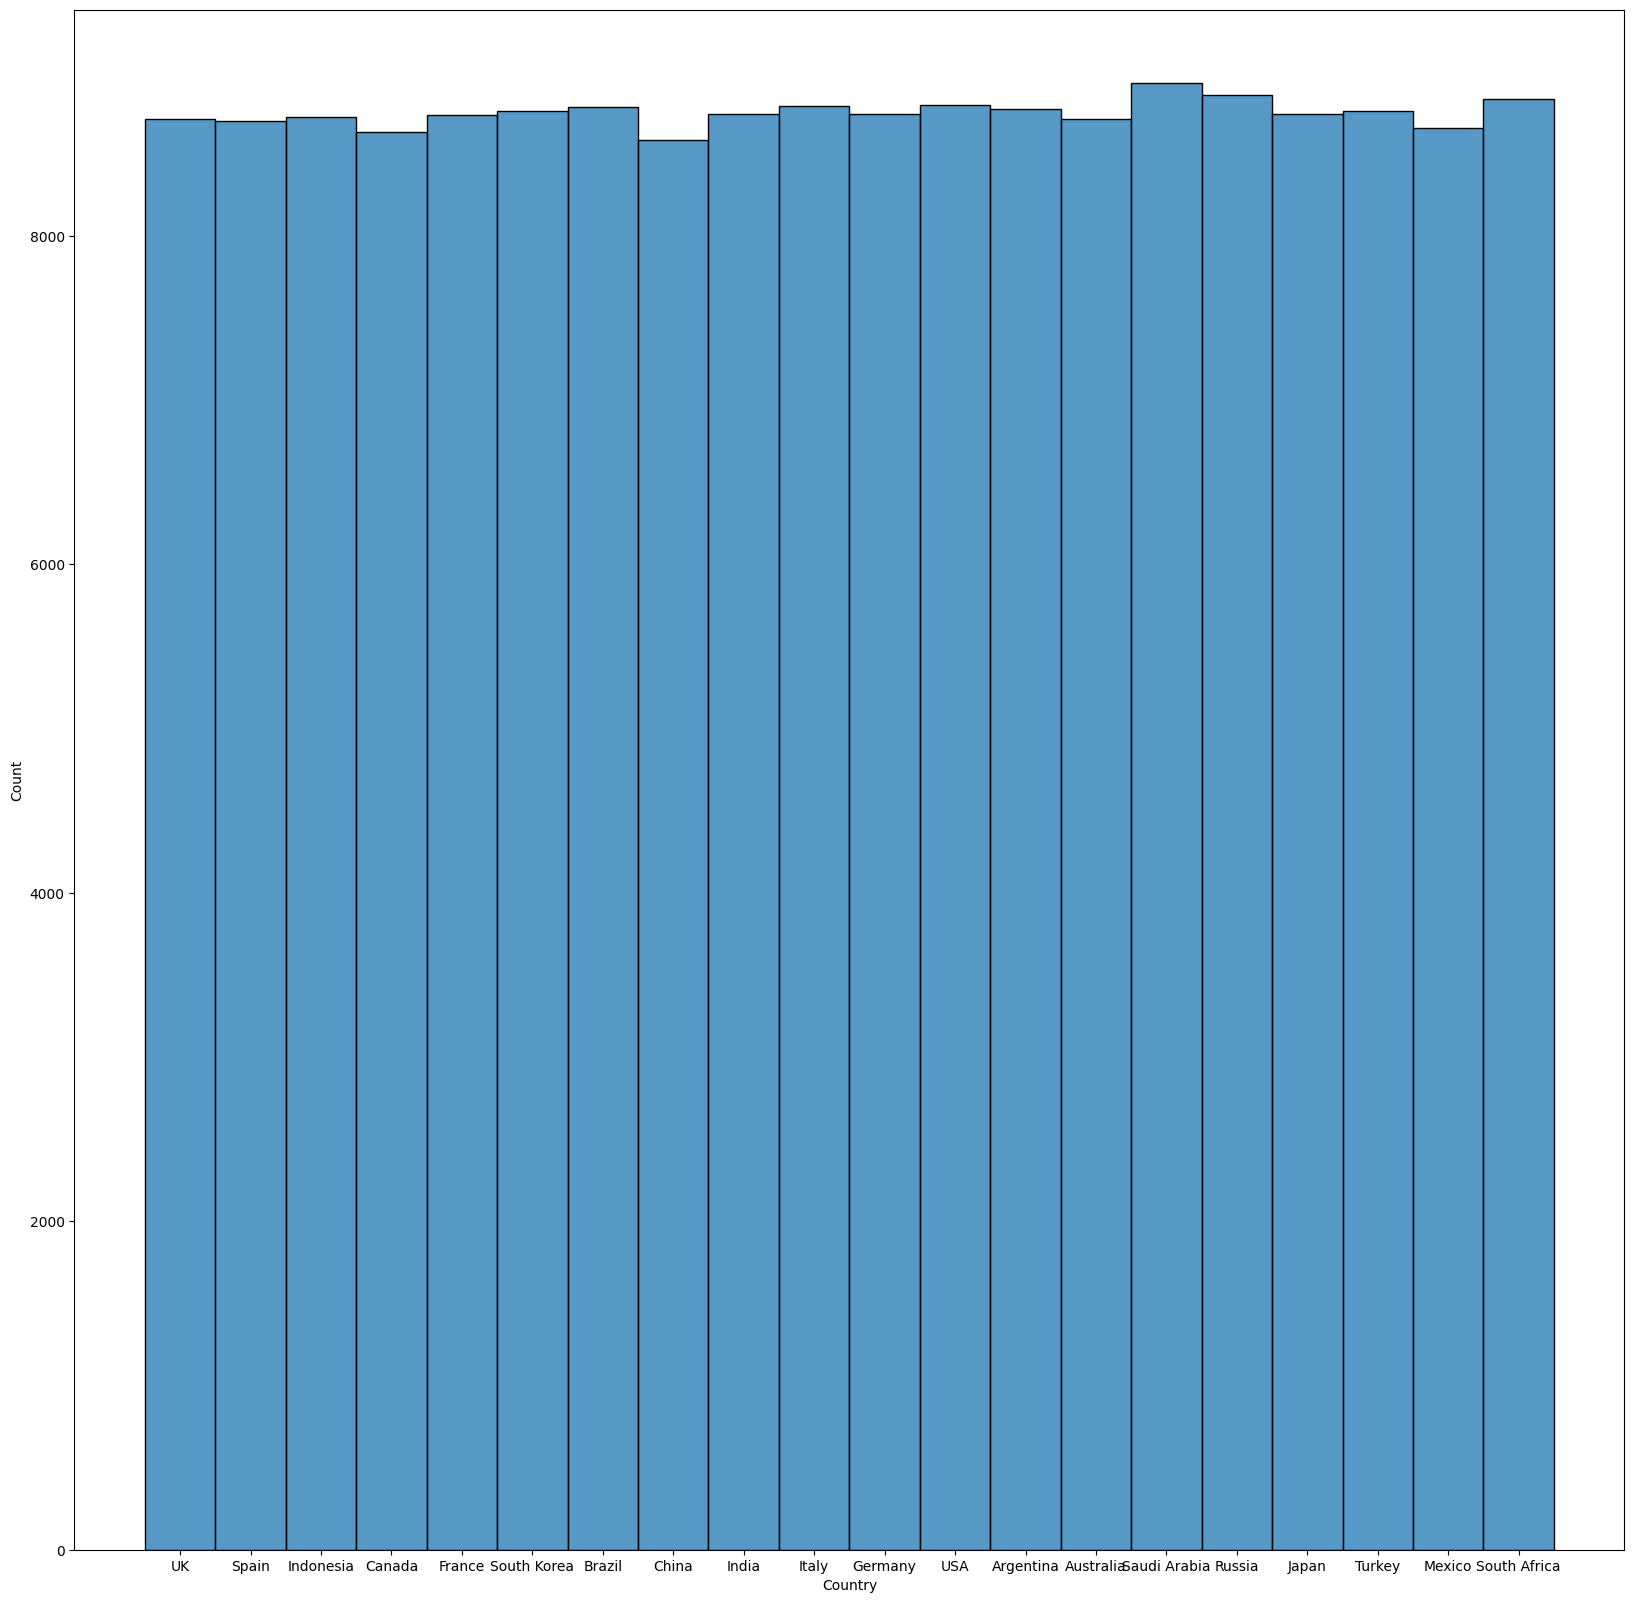

In [17]:
fig, ax = plt.subplots(figsize=(20, 20))
sns.histplot(data=df, x="Country", ax=ax)
plt.show()

<Axes: xlabel='Age', ylabel='BMI'>

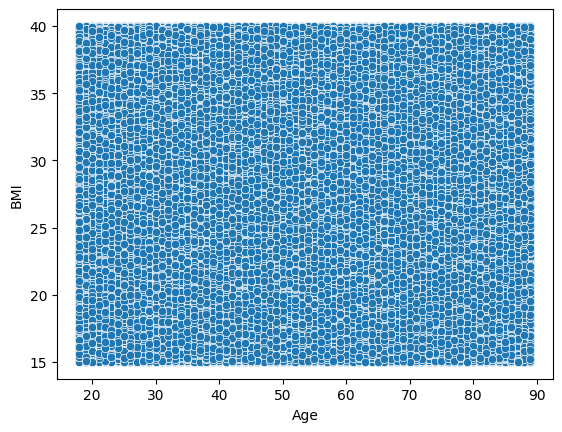

In [18]:
sns.scatterplot(data=df, x="Age",y="BMI")

In [19]:
df[["Age", "BMI"]].corr()

,Age,BMI
Age,1.000000,-0.003456
BMI,-0.003456,1.000000


<Axes: xlabel='Age', ylabel='Alcohol_Intake'>

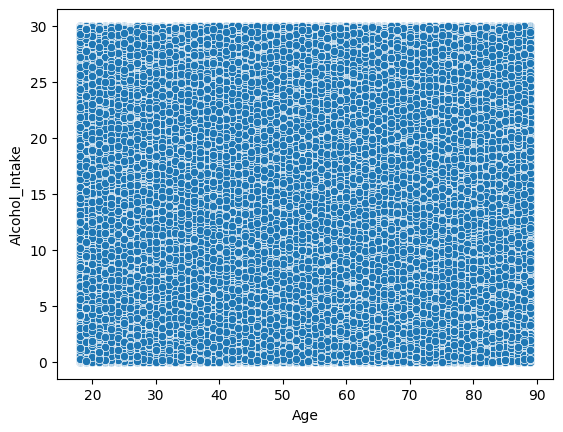

In [20]:
sns.scatterplot(data=df, x="Age",y="Alcohol_Intake")

In [21]:
df[["Age", "Alcohol_Intake"]].corr()

,Age,Alcohol_Intake
Age,1.000000,0.001643
Alcohol_Intake,0.001643,1.000000


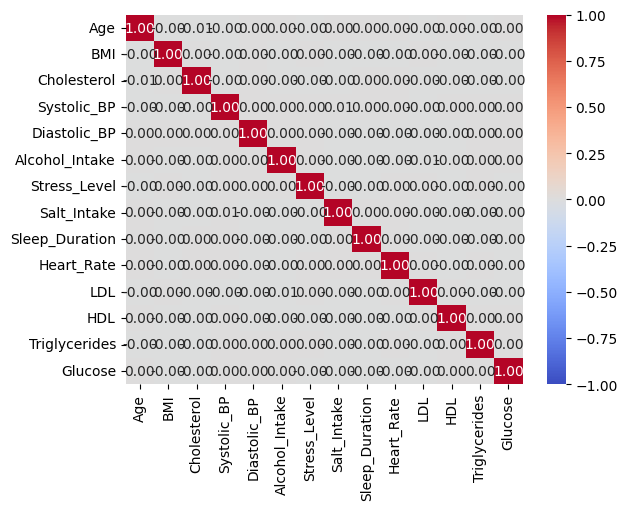

In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.show()

In [ ]:
sns.pairplot(df)


In [15]:
# Preprocessing: OneHotEncode categorical + scale numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numeric", StandardScaler(), numeric_cols)
    ]
)




In [17]:
# Train-test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [20]:
# KNN model with k = 5
knn = KNeighborsClassifier(n_neighbors=5)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("knn", knn)
])





In [22]:
# Fit model
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)


In [23]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6581992742235049

Classification report:
              precision    recall  f1-score   support

        High       0.72      0.86      0.78     25157
         Low       0.28      0.14      0.18      9840

    accuracy                           0.66     34997
   macro avg       0.50      0.50      0.48     34997
weighted avg       0.60      0.66      0.62     34997


Confusion matrix:
[[21681  3476]
 [ 8486  1354]]


In [25]:

# Test for best K from 1 to 30
param_grid = {
    'knn__n_neighbors': list(range(1, 31))
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)



,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('categorical', ...), ('numeric', ...)]"


In [26]:
print("Best K:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


Best K: {'knn__n_neighbors': 30}
Best CV accuracy: 0.7175697396149588
